# Importación de los Datos
En esta sección, importamos el archivo Excel 'Datos_Stat_Model_Excel.xlsx' utilizando la biblioteca pandas. 
El archivo contiene datos sobre mezclas de concreto, incluyendo fechas, diseños, zonas, volúmenes, turnos, humedad y cantidades de materiales. 
Convertimos la columna 'FECHA' (formato serial de Excel) a fechas legibles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns

# Leer el archivo CSV con la codificación correcta
df = pd.read_csv('Datos_Stat_Model.csv', encoding='utf-8-sig')

# Verificar si la columna 'FECHA' existe antes de convertirla
df['Date'] = pd.to_datetime(df['FECHA'], format='%m/%d/%Y', errors='coerce')

# Eliminar filas con valores nulos en la columna 'Date'
df = df.dropna(subset=['Date'])

# Mostrar las primeras filas
df.head()

,FECHA,Diseño de la Mezcla,Zona,Volumen (m3),TURNO,Humedad arena (%),Arena (kg),Grava (kg),Cemento (kg),Agua (kg),RHEO 1000 (kg),BASF 719 (kg),Delvo (litros),MasterGlenium 7950,MasterGlenium 7970,Sika PP 48 (kg)-BARCHIP,Date
0,1/1/2023,Shotcrete-35MPa-Development,ZONA_QJ3408,5.5,DIA,0.047,8750.0,0.0,2822.0,890.0,47.3,16.5,5.5,0.0,0.0,22.0,2023-01-01
1,1/1/2023,Shotcrete-35MPa-Development,ZONA_QJ3408,5.0,DIA,0.047,7950.0,0.0,2565.0,810.0,43.0,15.0,5.0,0.0,0.0,20.0,2023-01-01
2,1/1/2023,Shotcrete-35MPa-Development,ZONA_MQ2351,6.0,DIA,0.047,9540.0,0.0,3080.0,960.0,51.6,18.0,6.0,0.0,0.0,24.0,2023-01-01
3,1/1/2023,Shotcrete-35MPa-Development,ZONA_LD2830,6.0,DIA,0.047,9545.0,0.0,3080.0,1000.0,51.6,18.0,6.0,0.0,0.0,24.0,2023-01-01
4,1/1/2023,Shotcrete-35MPa-Development,ZONA_KG8844,6.0,NOCHE,0.047,9540.0,0.0,3080.0,950.0,51.6,18.0,6.0,0.0,0.0,24.0,2023-01-01


## Análisis 1: Estadísticas Resumidas de Columnas Numéricas
### Descripción
Calculamos estadísticas descriptivas (media, mediana, desviación estándar, etc.) para columnas numéricas como  Arena, Grava, Cemento y Agua.

         Arena (kg)   Grava (kg)  Cemento (kg)    Agua (kg)
count   8621.000000  8621.000000   8621.000000  8621.000000
mean    7319.092561  1141.981839   2285.110229   633.118061
std     2989.373391  1981.125269    826.481100   346.059538
min        0.000000     0.000000    105.000000     0.000000
25%     5159.364500     0.000000   1800.000000   447.177500
50%     8502.771285     0.000000   2700.000000   646.239600
75%     9885.046200  1643.424000   2850.000000   770.953800
max    13568.299200  6678.424000   4320.000000  2230.400000


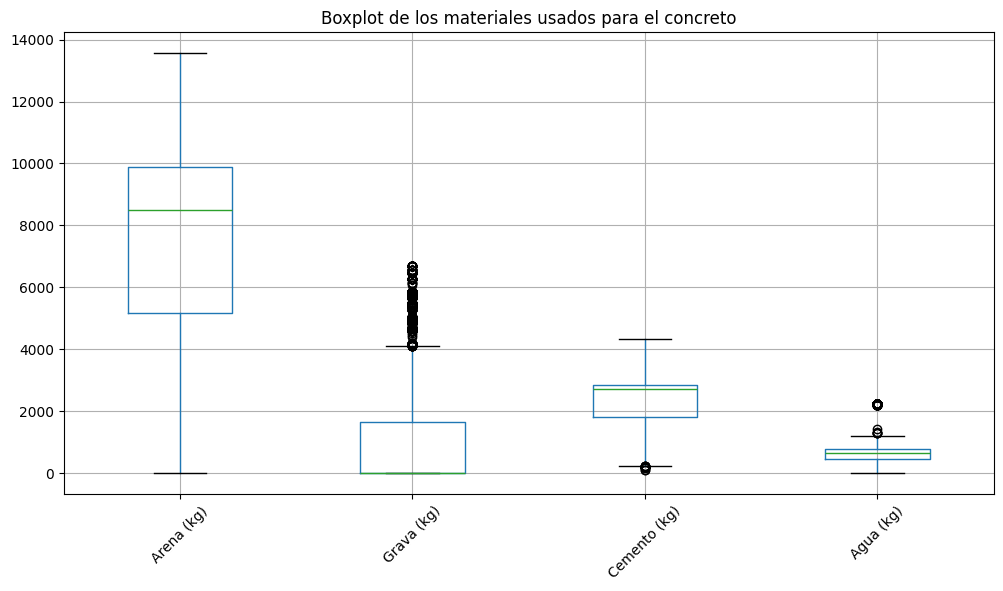

In [2]:
# Resultados numéricos
summary = df[['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)']].describe()
print(summary)

# Gráfico: Boxplot de variables numéricas
plt.figure(figsize=(12, 6))
df[['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)']].boxplot()
plt.title('Boxplot de los materiales usados para el concreto')
plt.xticks(rotation=45)
plt.show()

## Análisis 2: Distribución de Diseños de Mezcla
### Descripción
Contamos la frecuencia de cada tipo de 'Diseño de la Mezcla' para entender cuáles son los más comunes.

Diseño de la Mezcla
DIS_XB915                      2291
DIS_PZ496                      1349
DIS_BI322                       940
DIS_WZ815                       808
DIS_MU573                       674
DIS_ZQ491                       468
Shotcrete-35MPa-Development     311
DIS_KL084                       301
DIS_YV593                       291
DIS_FO901                       264
DIS_JN153                       239
DIS_ME258                       214
DIS_IO769                       187
DIS_UE958                       163
Concrete-21 Mpa                  20
DIS_NK806                        19
Concrete-35 Mpa                  17
DIS_OF495                        11
DIS_NX500                         9
DIS_BI843                         6
Concrete-28 Mpa                   5
Concrete-10 Mpa                   5
DIS_QD254                         4
Concrete-25 Mpa                   4
DIS_YL594                         4
DIS_YV623                         3
DIS_AL891                         3
DIS_XZ98

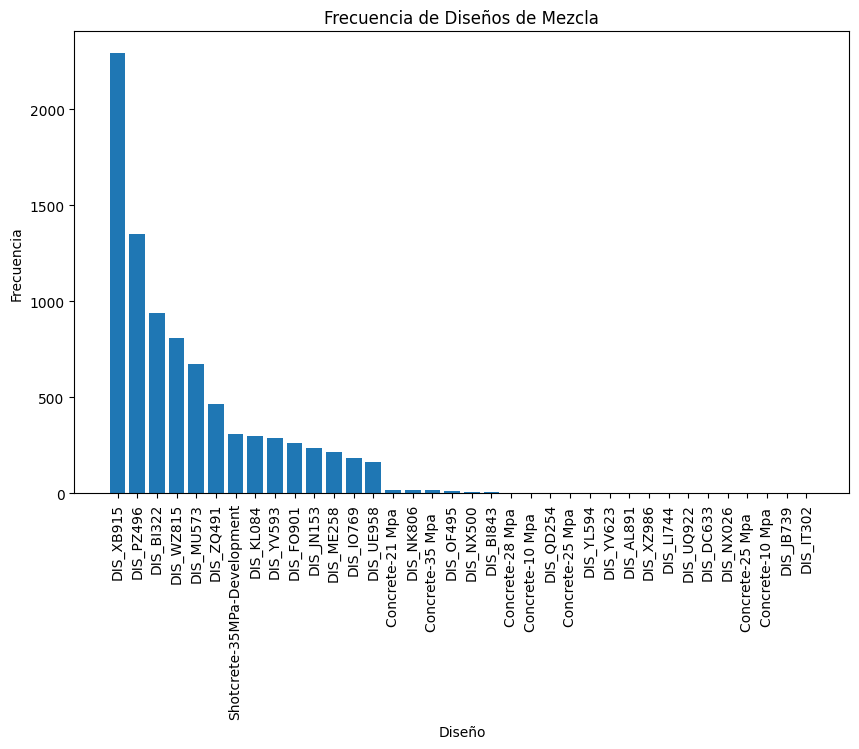

In [3]:
# Resultados numéricos
mix_counts = df['Diseño de la Mezcla'].value_counts()
print(mix_counts)

# Gráfico: Bar plot
plt.figure(figsize=(10, 6))
plt.bar(mix_counts.index, mix_counts.values)
plt.title('Frecuencia de Diseños de Mezcla')
plt.xlabel('Diseño')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

### Conclusión
El diseño más común es 'Shotcrete-35MPa-Development', representando la mayoría de las entradas, lo que indica su uso predominante.

## Análisis 3: Scatter plot


Matriz de Correlación:
              Arena (kg)  Grava (kg)  Cemento (kg)  Agua (kg)  Volumen (m3)
Arena (kg)      1.000000   -0.283436      0.731678   0.146737      0.845089
Grava (kg)     -0.283436    1.000000     -0.205372  -0.010579      0.181471
Cemento (kg)    0.731678   -0.205372      1.000000   0.705451      0.822840
Agua (kg)       0.146737   -0.010579      0.705451   1.000000      0.417468
Volumen (m3)    0.845089    0.181471      0.822840   0.417468      1.000000


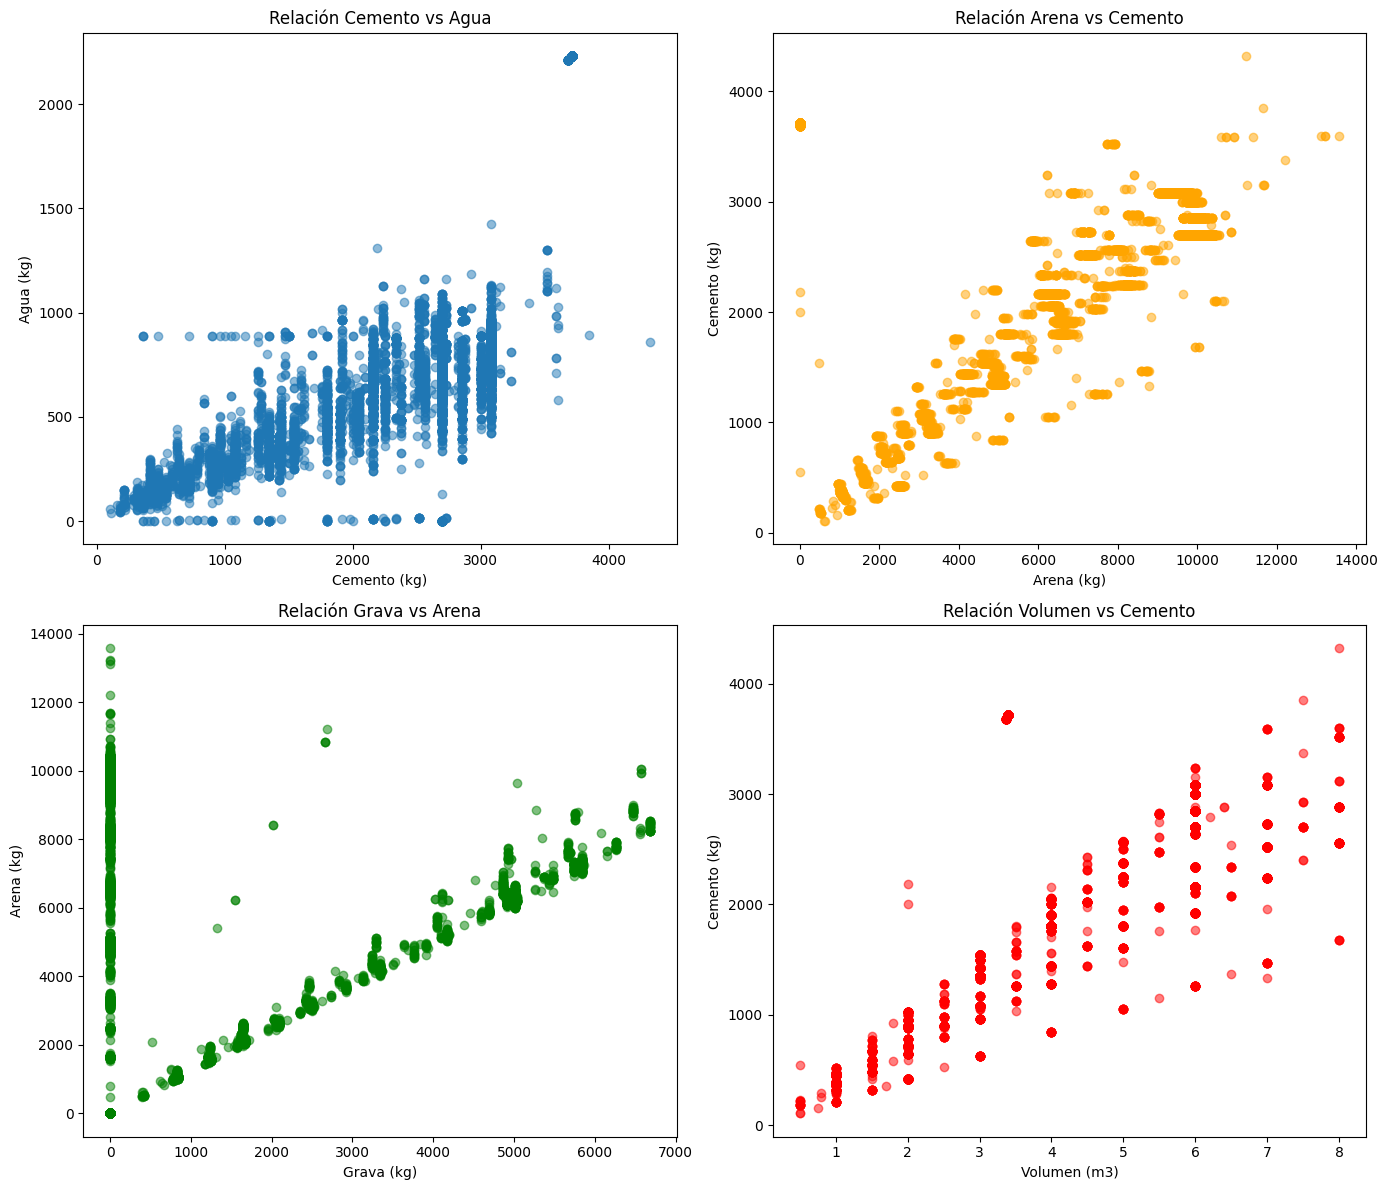

In [4]:
# Resultados numéricos: Correlación entre variables
correlation_matrix = df[['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)', 'Volumen (m3)']].corr()
print("Matriz de Correlación:")
print(correlation_matrix)

# Gráfico: Scatter plot matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter 1: Cemento vs Agua
axes[0, 0].scatter(df['Cemento (kg)'], df['Agua (kg)'], alpha=0.5)
axes[0, 0].set_xlabel('Cemento (kg)')
axes[0, 0].set_ylabel('Agua (kg)')
axes[0, 0].set_title('Relación Cemento vs Agua')

# Scatter 2: Arena vs Cemento
axes[0, 1].scatter(df['Arena (kg)'], df['Cemento (kg)'], alpha=0.5, color='orange')
axes[0, 1].set_xlabel('Arena (kg)')
axes[0, 1].set_ylabel('Cemento (kg)')
axes[0, 1].set_title('Relación Arena vs Cemento')

# Scatter 3: Grava vs Arena
axes[1, 0].scatter(df['Grava (kg)'], df['Arena (kg)'], alpha=0.5, color='green')
axes[1, 0].set_xlabel('Grava (kg)')
axes[1, 0].set_ylabel('Arena (kg)')
axes[1, 0].set_title('Relación Grava vs Arena')

# Scatter 4: Volumen vs Cemento
axes[1, 1].scatter(df['Volumen (m3)'], df['Cemento (kg)'], alpha=0.5, color='red')
axes[1, 1].set_xlabel('Volumen (m3)')
axes[1, 1].set_ylabel('Cemento (kg)')
axes[1, 1].set_title('Relación Volumen vs Cemento')

plt.tight_layout()
plt.show()

### Conclusión
Ciertas zonas como ZONA_QJ3408 tienen volúmenes significativamente mayores, indicando áreas de alta actividad.

## Análisis 4: Tendencia de consumo de Cemento Total Diario
### Descripción
Agrupamos por fecha y sumamos la cantidad de cemento para ver la tendencia temporal.

count    1071.000000
mean       40.581989
std        20.259645
min         1.500000
25%        28.000000
50%        37.500000
75%        49.675000
max       246.000000
Name: Volumen (m3), dtype: float64


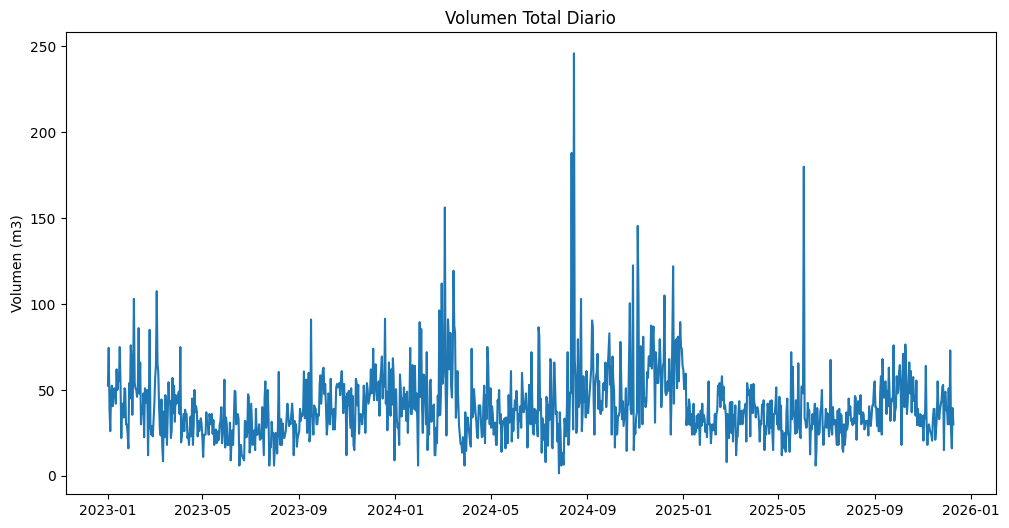

In [5]:
# Resultados numéricos
daily_volume = df.groupby('Date')['Volumen (m3)'].sum()
print(daily_volume.describe())

# Gráfico: Line plot
plt.figure(figsize=(12, 6))
plt.plot(daily_volume.index, daily_volume.values)
plt.title('Volumen Total Diario')
plt.ylabel('Volumen (m3)')
plt.show()

### Conclusión
El consumo de cemento diario varía, con picos en ciertas fechas, posiblemente correlacionado con proyectos específicos.

## Análisis 5: Boxplot de Volumen por Diseño de Mezcla
### Descripción
Visualizamos la distribución de volúmenes por tipo de mezcla.

                              count         mean          std     min  \
Diseño de la Mezcla                                                     
Concrete-10 Mpa                 1.0   420.000000          NaN   420.0   
Concrete-10 Mpa                 5.0   946.000000   478.988518   110.0   
Concrete-21 Mpa                20.0  1600.000000   704.153093   320.0   
Concrete-25 Mpa                 4.0  1800.000000   974.884609   360.0   
Concrete-25 Mpa                 1.0   720.000000          NaN   720.0   
Concrete-28 Mpa                 5.0  1833.000000   697.653209   975.0   
Concrete-35 Mpa                17.0  2481.176471   840.252063   440.0   
DIS_AL891                       3.0  2880.000000   623.538291  2160.0   
DIS_BI322                     940.0  1809.000000   578.906703   180.0   
DIS_BI843                       6.0  2745.000000  1175.869891   810.0   
DIS_DC633                       1.0  1330.000000          NaN  1330.0   
DIS_FO901                     264.0  2721.590909   

C:\Users\DELL PC\AppData\Local\Temp\ipykernel_8036\4057898760.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=df['Diseño de la Mezcla'].unique())


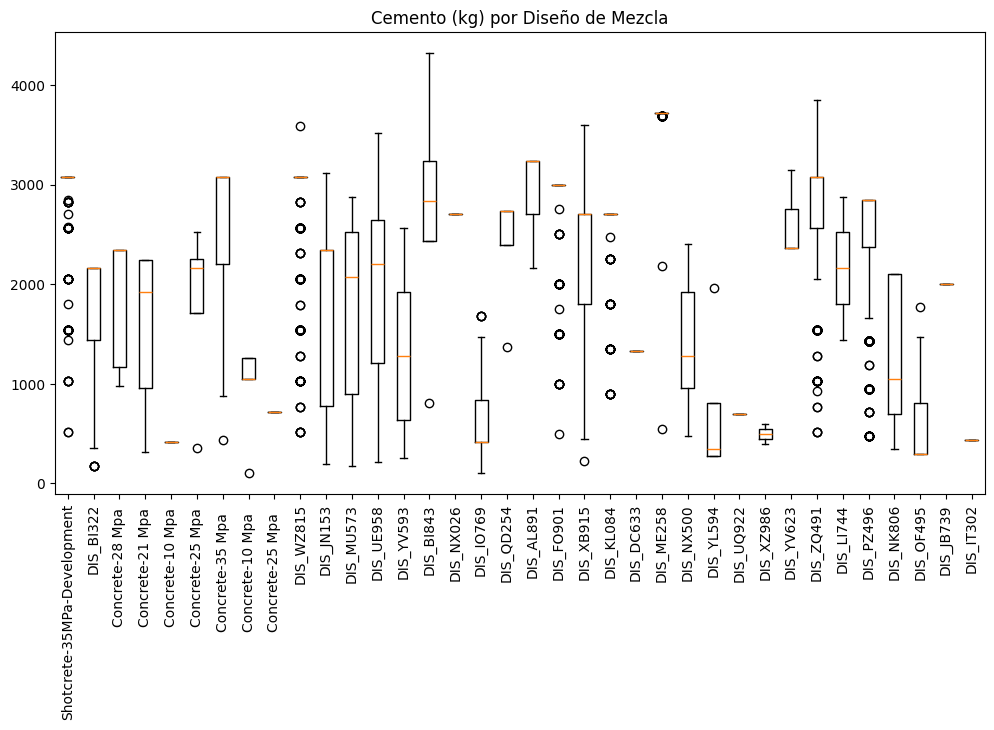

In [6]:
# Resultados numéricos
volume_by_mix = df.groupby('Diseño de la Mezcla')['Cemento (kg)'].describe()
print(volume_by_mix)

# Gráfico: Boxplot
plt.figure(figsize=(12, 6))
data_to_plot = [df[df['Diseño de la Mezcla'] == mix]['Cemento (kg)'] for mix in df['Diseño de la Mezcla'].unique()]
plt.boxplot(data_to_plot, labels=df['Diseño de la Mezcla'].unique())
plt.title('Cemento (kg) por Diseño de Mezcla')
plt.xticks(rotation=90)
plt.show()

### Conclusión
Algunos diseños tienen volúmenes más consistentes, mientras que otros varían más.

## Análisis 6: Histograma de Humedad de Arena
### Descripción
Mostramos la distribución de la humedad de la arena.

         Arena (kg)   Grava (kg)  Cemento (kg)    Agua (kg)
count   8621.000000  8621.000000   8621.000000  8621.000000
mean    7319.092561  1141.981839   2285.110229   633.118061
std     2989.373391  1981.125269    826.481100   346.059538
min        0.000000     0.000000    105.000000     0.000000
25%     5159.364500     0.000000   1800.000000   447.177500
50%     8502.771285     0.000000   2700.000000   646.239600
75%     9885.046200  1643.424000   2850.000000   770.953800
max    13568.299200  6678.424000   4320.000000  2230.400000


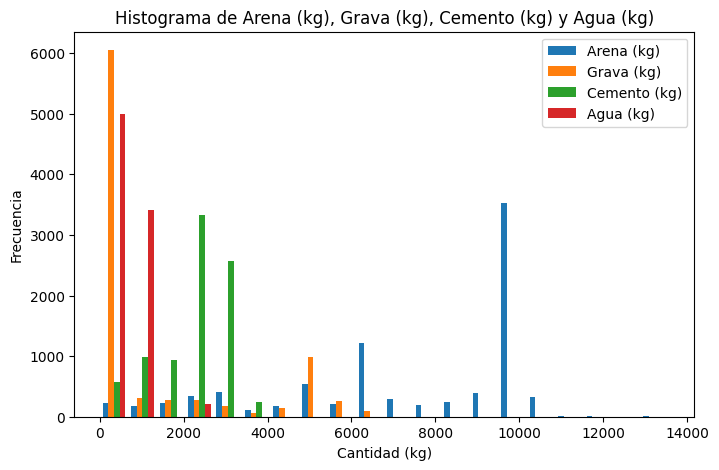

In [7]:
# Resultados numéricos
Histo_stats = df[['Arena (kg)','Grava (kg)','Cemento (kg)','Agua (kg)']].describe()
print(Histo_stats)

# Gráfico: Histogram
plt.figure(figsize=(8, 5))
plt.hist(df[['Arena (kg)','Grava (kg)','Cemento (kg)','Agua (kg)']], bins=20, label=['Arena (kg)','Grava (kg)','Cemento (kg)','Agua (kg)'])
plt.title('Histograma de Arena (kg), Grava (kg), Cemento (kg) y Agua (kg)')
plt.xlabel('Cantidad (kg)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Conclusión
La humedad se distribuye normalmente alrededor del 5-6%, con pocos valores extremos.

## Análisis 7: Uso Total de Materiales
### Descripción
Sumamos el uso total de cada material y visualizamos.

Arena (kg)      6.309790e+07
Grava (kg)      9.845025e+06
Cemento (kg)    1.969994e+07
Agua (kg)       5.458111e+06
dtype: float64


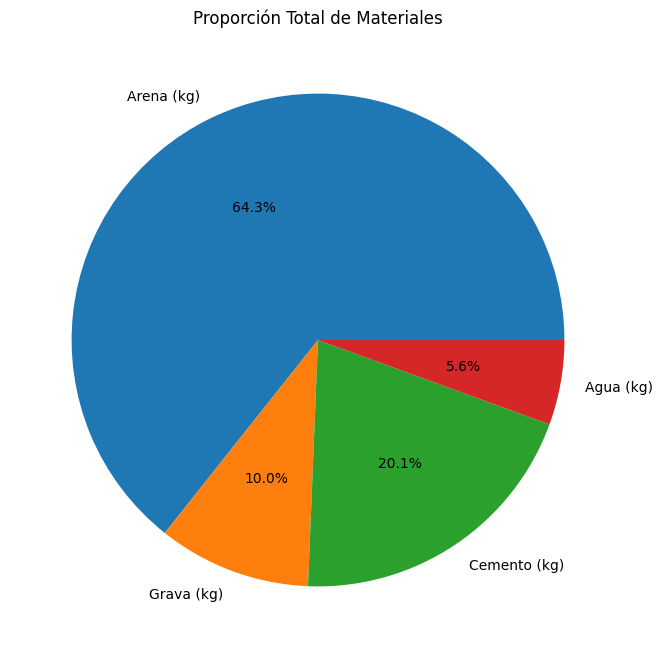

In [8]:
# Resultados numéricos
total_materials = df[['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)']].sum()
print(total_materials)

# Gráfico: Pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_materials.values, labels=total_materials.index, autopct='%1.1f%%')
plt.title('Proporción Total de Materiales')
plt.show()

### Conclusión
La arena y grava dominan el uso total, como se espera en mezclas de concreto.

# Análisis 8: Mapa de calor

              Arena (kg)  Grava (kg)  Cemento (kg)  Agua (kg)  Volumen (m3)
Arena (kg)      1.000000   -0.283436      0.731678   0.146737      0.845089
Grava (kg)     -0.283436    1.000000     -0.205372  -0.010579      0.181471
Cemento (kg)    0.731678   -0.205372      1.000000   0.705451      0.822840
Agua (kg)       0.146737   -0.010579      0.705451   1.000000      0.417468
Volumen (m3)    0.845089    0.181471      0.822840   0.417468      1.000000


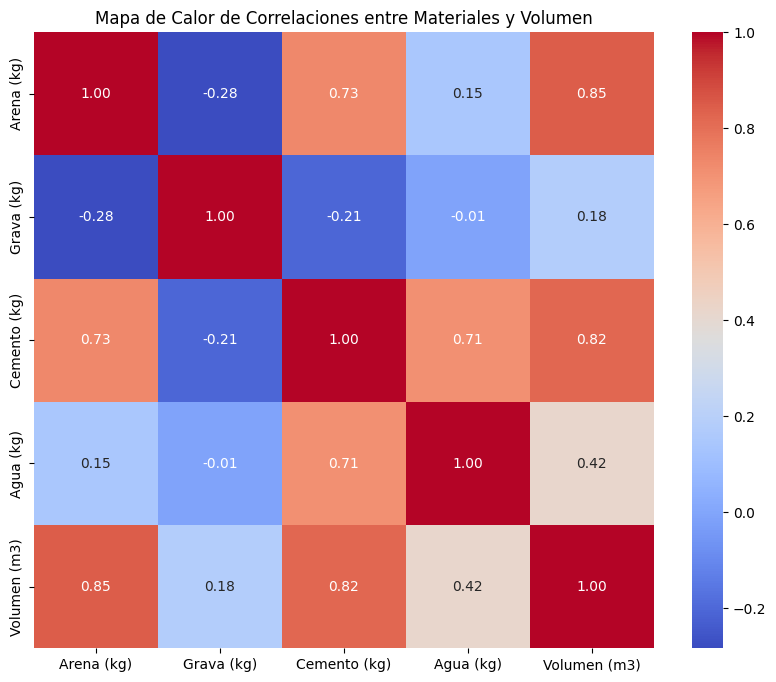

In [9]:
heatmap_data = df[['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)', 'Volumen (m3)']]
print(heatmap_data.corr())

plt.figure(figsize=(10, 8))
plt.title('Mapa de Calor de Correlaciones entre Materiales y Volumen')
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


# Análisis de todos los materiales

<Figure size 1600x1400 with 0 Axes>

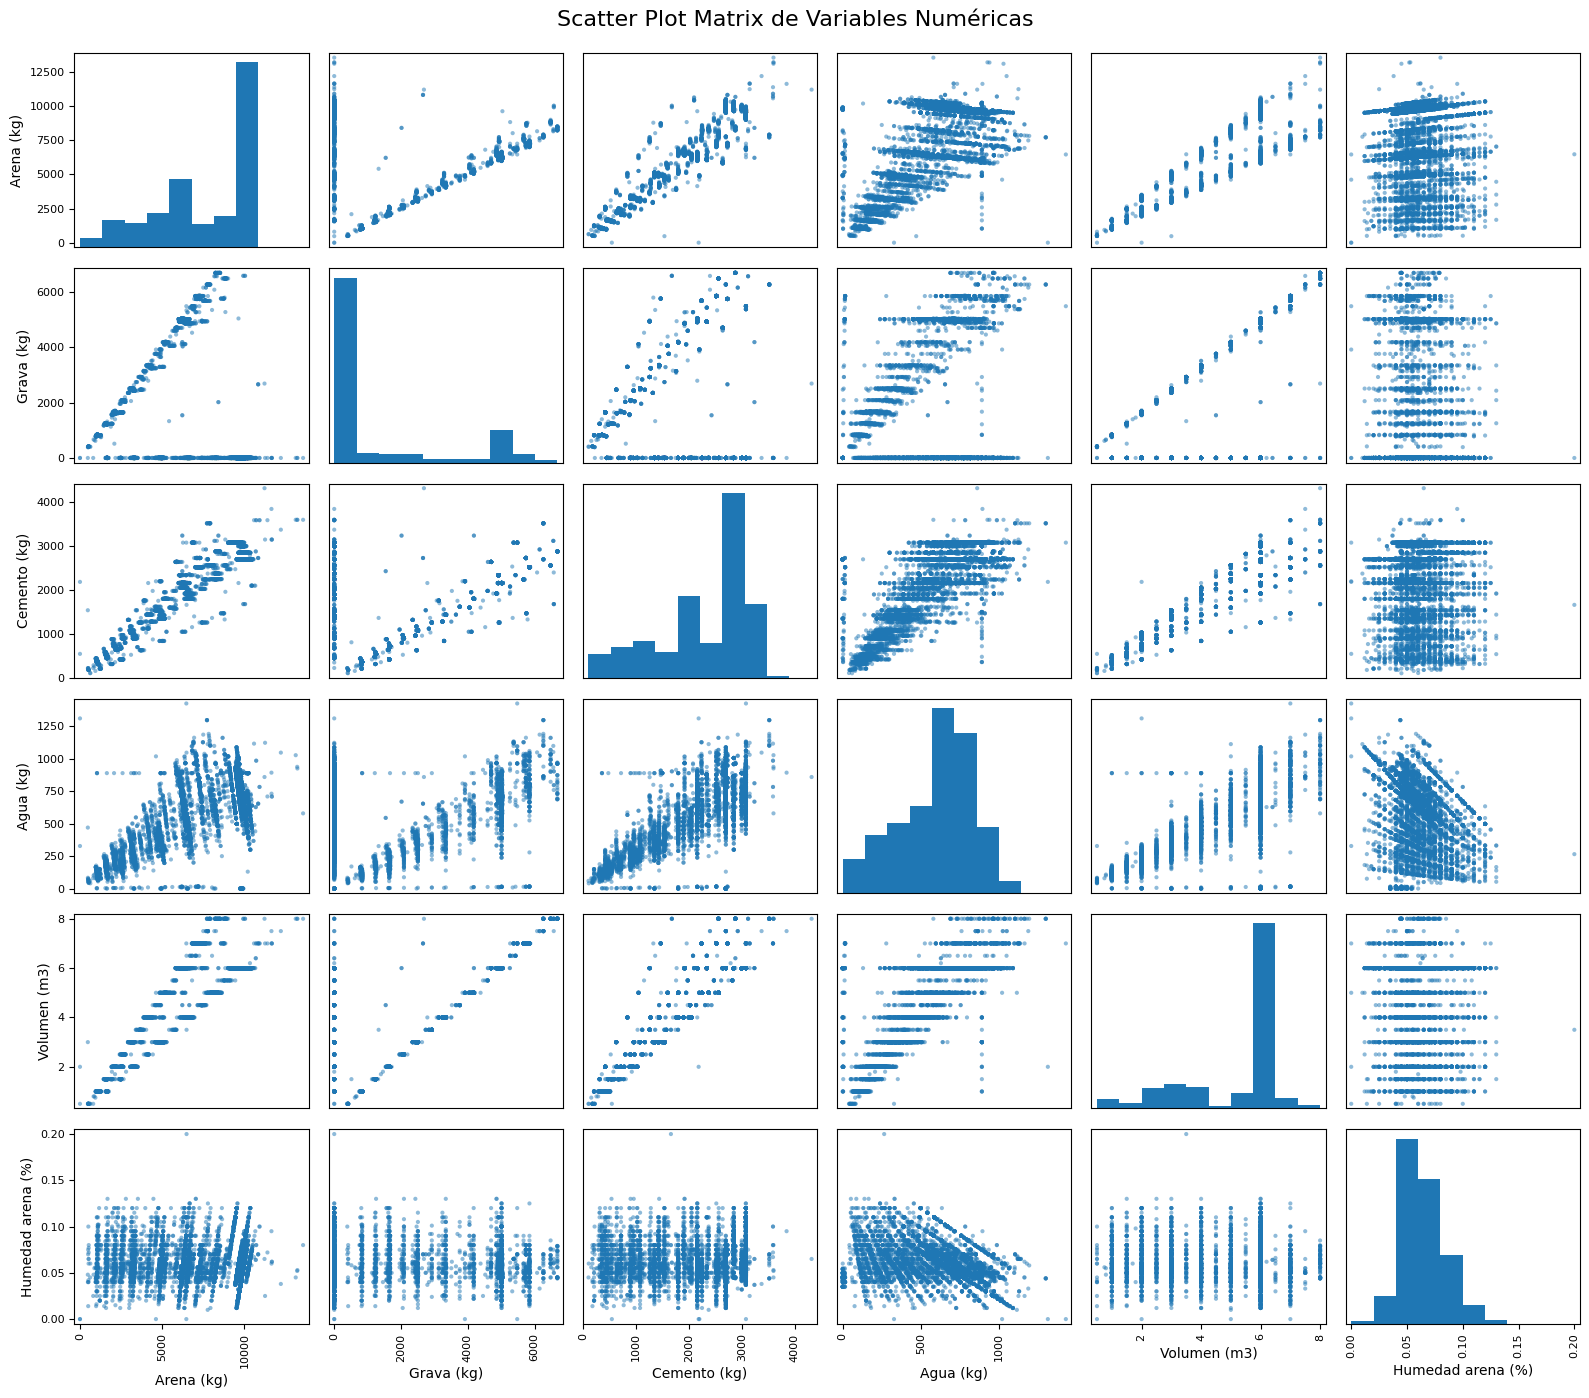

In [10]:
# Crear scatter plots de todas las variables numéricas
numeric_cols = ['Arena (kg)', 'Grava (kg)', 'Cemento (kg)', 'Agua (kg)', 'Volumen (m3)', 'Humedad arena (%)']

# Filtrar solo las columnas numéricas que existen en el dataframe
numeric_data = df[numeric_cols].dropna()

# Crear scatter plot matrix usando pandas
fig = plt.figure(figsize=(16, 14))
pd.plotting.scatter_matrix(numeric_data, alpha=0.5, figsize=(16, 14), diagonal='hist')
plt.suptitle('Scatter Plot Matrix de Variables Numéricas', y=0.995, fontsize=16)
plt.tight_layout()
plt.show()

       RHEO 1000 (kg)  BASF 719 (kg)  Delvo (litros)  MasterGlenium 7950  \
count     8621.000000    8621.000000     8621.000000         8621.000000   
mean         9.165669       5.288202        7.005062           19.415128   
std         15.956578       7.434053        6.422188           19.439722   
min          0.000000       0.000000        0.000000            0.000000   
25%          0.000000       0.000000        0.000000            0.000000   
50%          0.000000       0.000000        6.000000           17.100000   
75%         12.960000      12.960000       13.500000           37.800000   
max         60.200000      65.000000       26.925000           71.175000   

       MasterGlenium 7970  Sika PP 48 (kg)-BARCHIP  
count         8621.000000              8621.000000  
mean             0.014230                17.500116  
std              0.395214                13.546992  
min              0.000000                 0.000000  
25%              0.000000                 0.000000

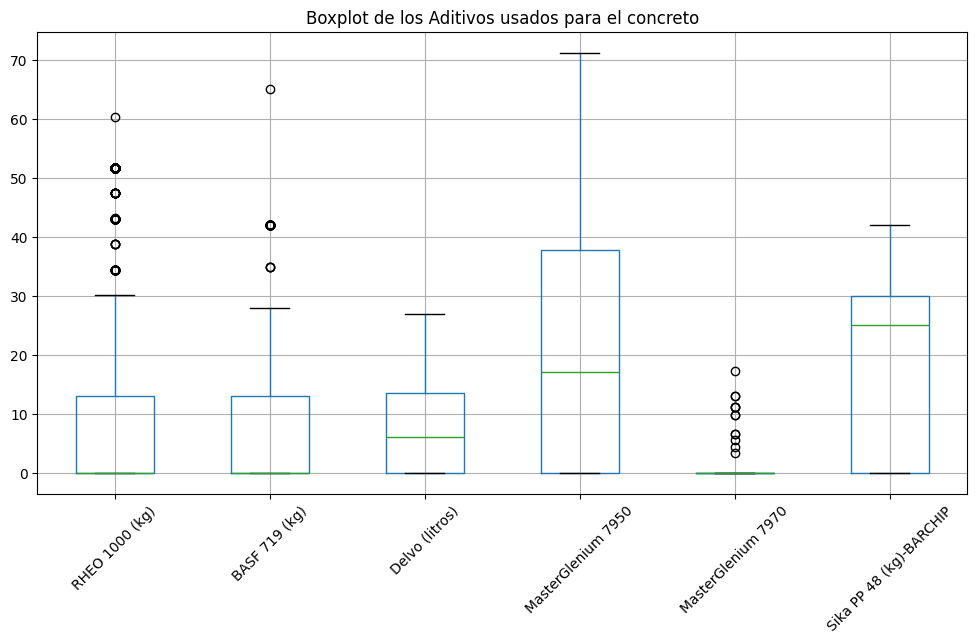

In [11]:
# Estadísticas descriptivas de los aditivos
aditivo_stats = df[['RHEO 1000 (kg)', 'BASF 719 (kg)', 'Delvo (litros)', 'MasterGlenium 7950', 'MasterGlenium 7970', 'Sika PP 48 (kg)-BARCHIP']].describe()
print(aditivo_stats)

# Gráfico: Boxplot de los aditivos
plt.figure(figsize=(12, 6))
df[['RHEO 1000 (kg)', 'BASF 719 (kg)', 'Delvo (litros)', 'MasterGlenium 7950', 'MasterGlenium 7970', 'Sika PP 48 (kg)-BARCHIP']].boxplot()
plt.title('Boxplot de los Aditivos usados para el concreto')
plt.xticks(rotation=45)
plt.show()

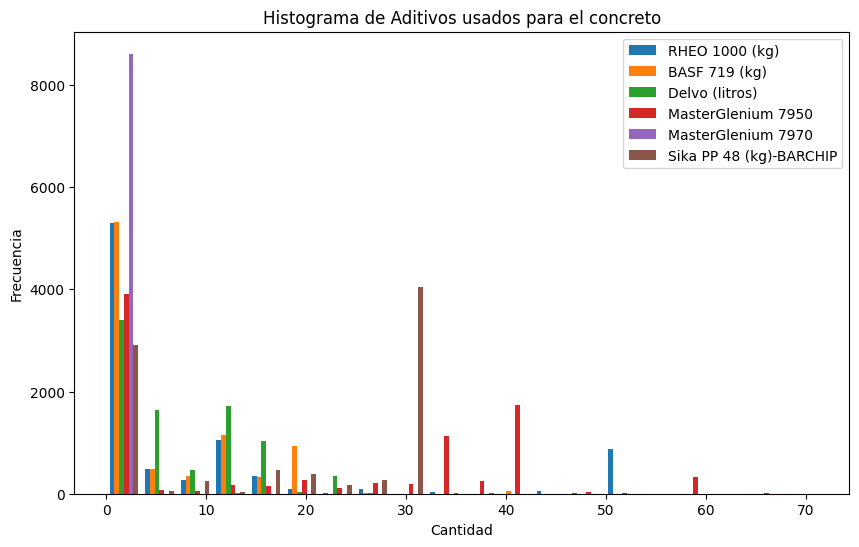

In [12]:
#Histograma de los aditivos
plt.figure(figsize=(10, 6))
plt.hist(df[['RHEO 1000 (kg)', 'BASF 719 (kg)', 'Delvo (litros)', 'MasterGlenium 7950', 'MasterGlenium 7970', 'Sika PP 48 (kg)-BARCHIP']], bins=20, label=['RHEO 1000 (kg)', 'BASF 719 (kg)', 'Delvo (litros)', 'MasterGlenium 7950', 'MasterGlenium 7970', 'Sika PP 48 (kg)-BARCHIP'])
plt.title('Histograma de Aditivos usados para el concreto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

Matriz de Correlación de Aditivos:
                         RHEO 1000 (kg)  BASF 719 (kg)  Delvo (litros)  \
RHEO 1000 (kg)                 1.000000       0.803865       -0.290490   
BASF 719 (kg)                  0.803865       1.000000       -0.524127   
Delvo (litros)                -0.290490      -0.524127        1.000000   
MasterGlenium 7950            -0.564518      -0.649036        0.878610   
MasterGlenium 7970            -0.020685      -0.025616       -0.039279   
Sika PP 48 (kg)-BARCHIP        0.027966      -0.263739        0.820386   

                         MasterGlenium 7950  MasterGlenium 7970  \
RHEO 1000 (kg)                    -0.564518           -0.020685   
BASF 719 (kg)                     -0.649036           -0.025616   
Delvo (litros)                     0.878610           -0.039279   
MasterGlenium 7950                 1.000000           -0.006259   
MasterGlenium 7970                -0.006259            1.000000   
Sika PP 48 (kg)-BARCHIP            0.755251 

<Figure size 1600x1400 with 0 Axes>

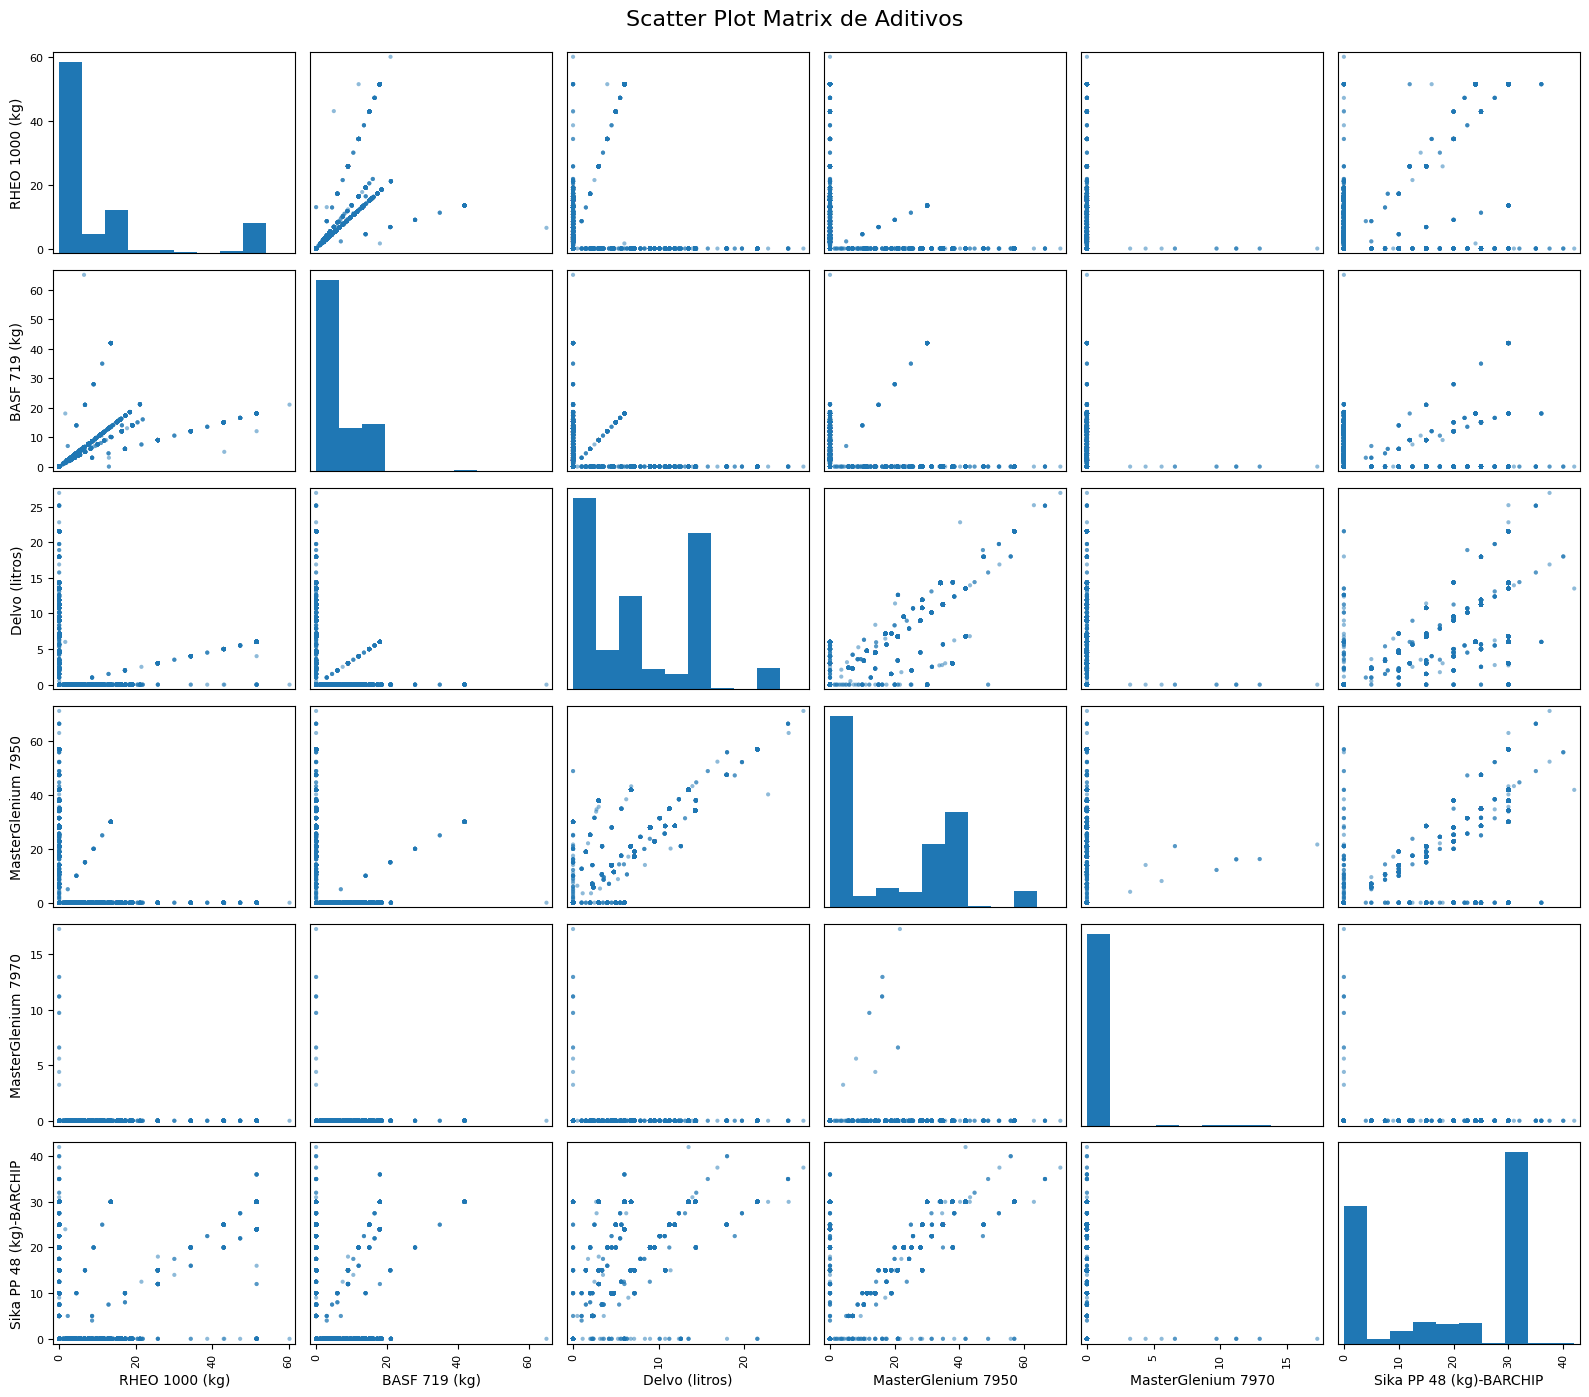

In [ ]:
# Scatter plot matrix de los aditivos y mapa de calor de correlaciones
aditivo_cols = ['RHEO 1000 (kg)', 'BASF 719 (kg)', 'Delvo (litros)', 'MasterGlenium 7950', 'MasterGlenium 7970', 'Sika PP 48 (kg)-BARCHIP']
scatter_data = df[aditivo_cols].dropna()
print("Matriz de Correlación de Aditivos:")
print(scatter_data.corr())

plt.figure(figsize=(16, 14))
pd.plotting.scatter_matrix(scatter_data, alpha=0.5, figsize=(16, 14), diagonal='hist')
plt.suptitle('Scatter Plot Matrix de Aditivos', y=0.995, fontsize=16)
plt.tight_layout()
plt.show()

# Heatmap de correlación de aditivos
plt.figure(figsize=(10, 8))
sns.heatmap(scatter_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación de Aditivos')
plt.show()

# Modelo  pkl para predecir el consumo de materiales a futuro

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Normalizar los datos
scaler = StandardScaler()
materiales = ['Arena (kg)', 'Grava (kg)', 'Cemento (kg)']
predicciones_futuras = {}

for material in materiales:
    # Preparar los datos
    X = df[['Date']].copy()
    X['Date'] = X['Date'].map(pd.Timestamp.toordinal)  # Convertir fechas a números ordinales
    X_scaled = scaler.fit_transform(X)  # Normalizar las fechas
    y = df[material]

    # Dividir los datos en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Crear y ajustar el modelo
    model = GradientBoostingRegressor(random_state=42)
    model.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Métricas para {material}: MSE={mse}, R2={r2}")

    # Predicciones futuras
    future_dates = pd.date_range(start=df['Date'].max(), periods=365)
    future_ordinal = future_dates.map(pd.Timestamp.toordinal).to_frame(name='Date')
    future_scaled = scaler.transform(future_ordinal)  # Normalizar las fechas futuras
    future_predictions = model.predict(future_scaled)

    # Guardar las predicciones
    predicciones_futuras[material] = pd.DataFrame({
        'Date': future_dates,
        'Predicción': future_predictions
    })

    # Graficar las predicciones
    plt.figure(figsize=(10, 6))
    plt.plot(df['Date'], df[material], label='Datos históricos')
    plt.plot(future_dates, future_predictions, label='Predicción futura', linestyle='--')
    plt.title(f'Predicción futura para {material}')
    plt.xlabel('Fecha')
    plt.ylabel(material)
    plt.legend()
    plt.show()

# Mostrar las primeras filas de las predicciones para cada material
for material, predicciones in predicciones_futuras.items():
    print(f"Predicciones futuras para {material}:")
    print(predicciones.head())

NameError: name 'train_test_split' is not defined

Métricas para Arena (kg) con Random Forest: MSE=1242219.66995601, R2=0.8577728385977352


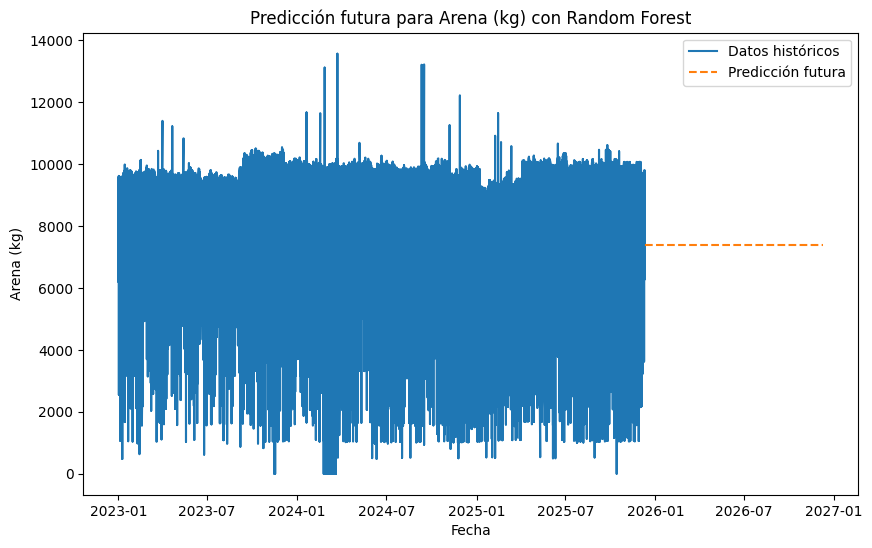

Métricas para Grava (kg) con Random Forest: MSE=2397688.940159579, R2=0.33946504162550817


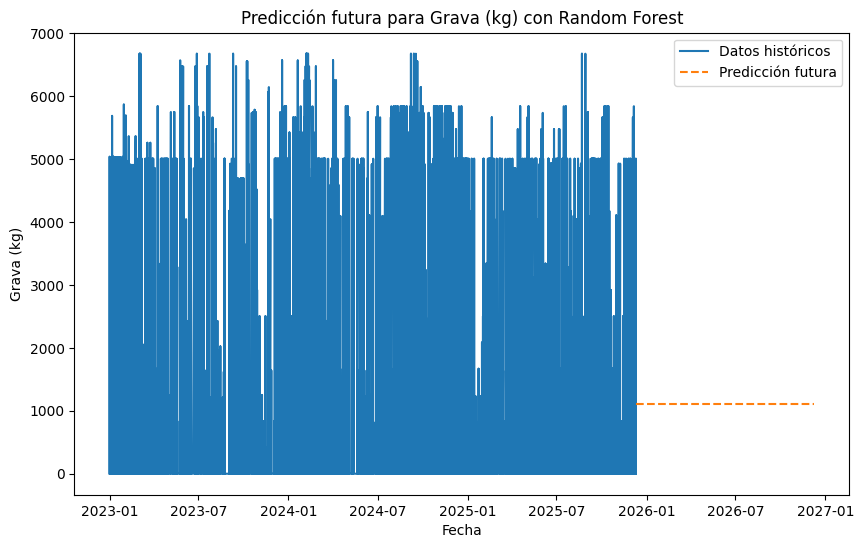

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Ajuste de hiperparámetros para Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

materiales = ['Arena (kg)', 'Grava (kg)', 'Cemento (kg)']
predicciones_futuras_rf = {}

for material in materiales:
    # Preparar los datos
    X = df[['Date', 'Volumen (m3)', 'Humedad arena (%)']].copy()
    X['Date'] = X['Date'].map(pd.Timestamp.toordinal)  # Convertir fechas a números ordinales
    y = df[material]

    # Dividir los datos en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Crear el modelo base
    rf = RandomForestRegressor(random_state=42)

    # Ajuste de hiperparámetros
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='r2')
    grid_search.fit(X_train, y_train)

    # Mejor modelo
    best_rf = grid_search.best_estimator_

    # Predicciones en el conjunto de prueba
    y_pred = best_rf.predict(X_test)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Métricas para {material} con Random Forest: MSE={mse}, R2={r2}")

    # Predicciones futuras
    future_dates = pd.date_range(start=df['Date'].max(), periods=365)
    future_ordinal = future_dates.map(pd.Timestamp.toordinal)
    future_data = pd.DataFrame({
        'Date': future_ordinal,
        'Volumen (m3)': df['Volumen (m3)'].mean(),
        'Humedad arena (%)': df['Humedad arena (%)'].mean()
    })
    future_predictions = best_rf.predict(future_data)

    # Guardar las predicciones
    predicciones_futuras_rf[material] = pd.DataFrame({
        'Date': future_dates,
        'Predicción': future_predictions
    })

    # Graficar las predicciones
    plt.figure(figsize=(10, 6))
    plt.plot(df['Date'], df[material], label='Datos históricos')
    plt.plot(future_dates, future_predictions, label='Predicción futura', linestyle='--')
    plt.title(f'Predicción futura para {material} con Random Forest')
    plt.xlabel('Fecha')
    plt.ylabel(material)
    plt.legend()
    plt.show()

# Mostrar las primeras filas de las predicciones para cada material
for material, predicciones in predicciones_futuras_rf.items():
    print(f"Predicciones futuras para {material} con Random Forest:")
    print(predicciones.head())